## 0) Why Text Preprocessing Matters in NLP

Text is not data.<p>Text is a noisy digital artifact of human language — chaotic, inconsistent, context-dependent, and filled with artifacts from keyboards, browsers, and cultural conventions.<p>Before we can train models, we must **structure** the chaos.

## 1) Foundational Concepts

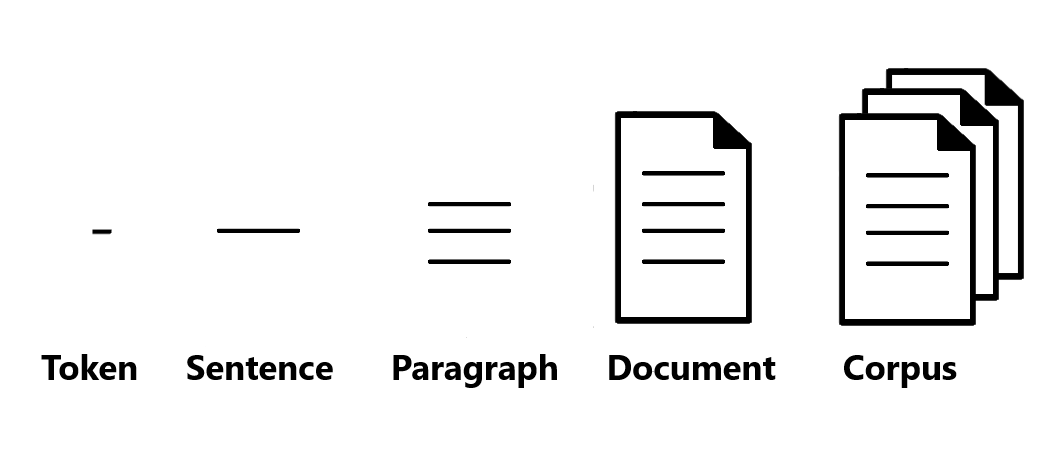

### 1.1) Corpus
A large, structured collection of text documents used for linguistic analysis or machine learning.

```python
corpus = [
    "I love this phone! Best purchase ever.",
    "Battery life is terrible. Very disappointed.",
    "Camera quality is amazing but expensive.",
    "Not worth the price. Returning it.",
    "Fast shipping and great customer service!"
]
```

**Real-world corpora:**

- IMDb reviews — 50,000 movie reviews
- Reuters news — 10,788 news articles
- Twitter sentiment — millions of tweets
- Wikipedia — entire knowledge base

**Why it matters:**<br>
Models learn patterns from corpora. Corpus quality determines model quality.

### 1.2) Document

A single text unit within a corpus.<br>
In the corpus above:

- `corpus[0]` is one document
- `corpus[1]` is another document

**Note:**
Document boundaries are task-dependent:

- Sentiment analysis: one review = one document
- Topic modeling: one article = one document
- Language modeling: entire book = one document

### 1.3) Sentence

A grammatical unit within a document, typically ending with `.`, `?`, or `!`.

*Example:*<br>
```python
document = "I love this phone! Best purchase ever."
# This contains TWO sentences
```
**Why sentence boundaries matter:**

- Summarization models need sentence-level understanding
- Machine translation operates sentence-by-sentence
- Some models use sentence embeddings

### 1.4) Token

The smallest unit of text processed by a model.<p>
Token = word
```python
text = "I love smartphone"
tokens = ["I", "love", "smartphone"]
```

Used in classical NLP pipelines

### 1.5) Vocabulary

The set of all unique tokens in corpus.<p>
*Example:*
```python
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    "I love this phone",
    "I hate this phone",
    "This phone is great"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

print(vectorizer.get_feature_names_out())
```

**Output:**
```python
['great' 'hate' 'is' 'love' 'phone' 'this']
```
**Vocabulary size:** 6 unique tokens


### 1.6) Type vs Token

**Type:** Unique word<br>
**Token:** Individual occurrence<br>
*Example:*
```python
text = "the cat sat on the mat"
```

- Tokens: 6 (total words)
- Types: 5 (unique words: "the", "cat", "sat", "on", "mat")

**Type-Token Ratio (TTR):**
```python
tokens = text.split()
types = set(tokens)
ttr = len(types) / len(tokens)
print(f"TTR: {ttr:.2f}")  # 0.83
```
High TTR = rich vocabulary

## 2) The Normalization pipeline

Real-world text is dirty.<br>
Here's what we're dealing with:

```python
raw_text = """
OMG!!! I can't believe this 𝓟𝓗𝓞𝓝𝓔 😍😍!!!
It's soooo amazng!!! 
Visit https://example.com NOW!!!
<p>This product isn't worth $999!!! It must be ½ off!!!</p>
Café prices vary.
   Too   many    spaces here.
The U.S. UNIVERSITY is advance.
"""
```

This contains:

- HTML tags (`<p>`)
- URLs
- Emojis (😍)
- Contractions ("can't", "isn't")
- Typos ("amazng")
- Repeated punctuation (`!!!`)
- Case inconsistencies ( UNVERSITY vs university)
- Unicode characters (`𝓟𝓗𝓞𝓝𝓔`, `½`)
- Multiple whitespaces
- Currency symbols (`$`)
- Abbreviations with periods (U.S.)

**Goal:**
Transform this into clean, structured tokens that models can learn from.

### 2.1) Unicode Normalization

Characters that look identical may have different Unicode representations.

Unicode normalization is a process that standardizes the representation of text in Unicode. It ensures that text is represented in a consistent and standardized way, regardless of the language or the platform it is being used on.

In [7]:
import unicodedata

# Method 1: Precomposed character (NFC)
text1 = "caf\u00E9"  # é as U+00E9 (single character)

# Method 2: Decomposed character (NFD) - manually constructed
text2 = "cafe\u0301"  # e (U+0065) + combining acute accent (U+0301)

print(f"Text 1: {text1}")
print(f"Text 2: {text2}")
print(f"Look the same? {text1} == {text2}")
print(f"Are they equal? {text1 == text2}")
print(f"Length of text1: {len(text1)}")
print(f"Length of text2: {len(text2)}")

# Show the actual bytes
print(f"\nText1 bytes: {text1.encode('utf-8')}")
print(f"Text2 bytes: {text2.encode('utf-8')}")

# Show character breakdown
print(f"\nText1 characters: {[c for c in text1]}")
print(f"Text2 characters: {[c for c in text2]}")

Text 1: café
Text 2: café
Look the same? café == café
Are they equal? False
Length of text1: 4
Length of text2: 5

Text1 bytes: b'caf\xc3\xa9'
Text2 bytes: b'cafe\xcc\x81'

Text1 characters: ['c', 'a', 'f', 'é']
Text2 characters: ['c', 'a', 'f', 'e', '́']


**Why This Happens:**

- Unicode Basics
- Unicode has multiple ways to represent the same visual character.

To solve this problem, we need to **normalize** the text. We will use the **NFKC** normalization form.<p>
**NFKC (Normalization Form Compatibility Composition)** is a Unicode normalization process that first applies compatibility decomposition (breaking down characters, mapping variants to a standard form) followed by canonical composition (combining characters into precomposed forms). It is best for creating a consistent, clean representation of text for search, sorting, and NLP by removing formatting distinctions. 

In [17]:
import unicodedata

normalized_text1 = unicodedata.normalize('NFKC', text1)
normalized_text2 = unicodedata.normalize('NFKC', text2)
print("Normalized Text 1:", normalized_text1)
print("Normalized Text 2:", normalized_text2)
normalized_text1 == normalized_text2

Normalized Text 1: café
Normalized Text 2: café


True

In [59]:
raw_text = """
OMG!!! I can't believe this 𝓟𝓗𝓞𝓝𝓔 😍😍!!!
It's soooo amazng!!! 
Visit https://example.com NOW!!!
<p>This product isn't worth $999!!! It must be ½ off!!!</p>
Café prices vary.
   Too   many    spaces here.
The U.S. UNIVERSITY is advance.
"""

In [60]:
import unicodedata

normalized_text = unicodedata.normalize('NFKC', raw_text)
print(normalized_text)


OMG!!! I can't believe this PHONE 😍😍!!!
It's soooo amazng!!! 
Visit https://example.com NOW!!!
<p>This product isn't worth $999!!! It must be 1⁄2 off!!!</p>
Café prices vary.
   Too   many    spaces here.
The U.S. UNIVERSITY is advance.



### 2.2) HTML Tag Removal

Web-scraped text contains HTML markup.


In [18]:
text = "<p>This phone is <b>amazing</b>!</p>"

We need the text not tags here.

#### Method 1: Using regex (Fragile)

In [19]:
import regex as re

text = "<p>This phone is <b>amazing</b>!</p>"
cleaned = re.sub(r'<.*?>', '', text)
print(cleaned) 

This phone is amazing!


But it breaks on nested or malformed HTML.

In [21]:
text = "<p>Price: <5 dollars</p>"
print(f"raw text: {text}")
cleaned = re.sub(r'<.*?>', '', text)
print(f"cleaned text: {cleaned}")

raw text: <p>Price: <5 dollars</p>
cleaned text: Price: 


#### Method 2: Using BeautifulSoup (Robust)

In [ ]:
from bs4 import BeautifulSoup

html_text = """
<html>
  <body>
    <p>This phone is <b>amazing</b>!</p>
    <div>Price: <5 dollars</div>
  </body>
</html>
"""

soup = BeautifulSoup(html_text, "lxml") # or "html.parser" but lxml is faster
text = soup.get_text(separator=" ", strip=True)
print(text)

This phone is amazing ! Price: <5 dollars


**Why BeautifulSoup?**

- Handles nested tags
- Preserves text with `<` or `>` symbols
- Extracts text from complex HTML structures

#### Production Function

In [ ]:
from bs4 import BeautifulSoup
def remove_html(text):
    """Remove HTML tags using BeautifulSoup"""
    soup = BeautifulSoup(text, "lxml")
    return soup.get_text(separator=" ", strip=True)

### 2.3) URL Removal

URLs add noise and don't contribute to most NLP tasks. 


#### Method 1: Using regex

In [ ]:
import regex as re
text = "NLP is wohooo. Visit https://NLP.com or www.usenlp.com for more info!"
print(f"Original: \n{text}")
cleaned = re.sub(r'http\S+|www\.\S+', '', text)
print(f"Cleaned: \n{cleaned}")

Original: 
NLP is wohooo. Visit https://NLP.com or www.usenlp.com for more info!
Cleaned: 
NLP is wohooo. Visit  or  for more info!


#### Method 2: Using spaCy

In [34]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 11.0 MB/s  0:00:01m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [108]:
import token
import spacy

nlp = spacy.load("en_core_web_sm")

text = "NLP is wohooo. Visit https://NLP.com or www.usenlp.com for more info!"
doc = nlp(text)

# Filter out URL tokens
clean_tokens = [token.text_with_ws for token in doc if not token.like_url]
cleaned = "".join(clean_tokens)

print(cleaned) 

NLP is wohooo. Visit or for more info!


**spaCy advantage:** 

Uses linguistic patterns, not just regex.

**When to use spaCy:**

- If our task is purely preprocessing text for ML and only need to remove URLs → regex is correct engineering.
- If our pipeline already uses spaCy for downstream tasks → removing URLs via like_url is almost free because the model is already loaded.

So using spaCy just for URL removal is computational overkill. Use the least powerful tool that solves the problem correctly.

- Not the fanciest.
- Not the fastest.
- The most appropriate.

And the universe is full of people using transformers to solve problems that regex solved perfectly in 1998. That’s technological inflation at its finest.

#### Production Function

In [106]:
import spacy
def remove_urls(text):
    """Remove URLs from text."""

    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)

    # Filter out URL tokens
    cleaned = "".join(token.text_with_ws for token in doc if not token.like_url)
    return cleaned

### 2.4) Contraction Expansion

Contractions break tokenization and lose semantic information.

```python
text = "I can't believe it's not working"
# Without expansion: ["I", "ca", "n't", "believe", "it", "'s", ...]
# Semantic loss: negation is fragmented

# Before expansion
"I don't like this" → tokens may lose "not" signal

# After expansion  
"I do not like this" → explicit negation
```

#### Method 1: Manual Dictionary Expansion

In [ ]:
contraction_map = {
    "can't": "cannot",
    "won't": "will not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "hasn't": "has not",
    "haven't": "have not",
    "hadn't": "had not",
    "doesn't": "does not",
    "don't": "do not",
    "didn't": "did not",
    "i'm": "i am",
    "you're": "you are",
    "he's": "he is",
    "she's": "she is",
    "it's": "it is",
    "we're": "we are",
    "they're": "they are",
    "i've": "i have",
    "you've": "you have",
    "we've": "we have",
    "they've": "they have",
    "i'd": "i would",
    "you'd": "you would",
    "he'd": "he would",
    "she'd": "she would",
    "we'd": "we would",
    "they'd": "they would",
    "i'll": "i will",
    "you'll": "you will",
    "he'll": "he will",
    "she'll": "she will",
    "we'll": "we will",
    "they'll": "they will"
}

def expand_contractions_manual(text):
    text_lower = text.lower()
    for contraction, expansion in contraction_map.items():
        text_lower = text_lower.replace(contraction, expansion)
    return text_lower

text = "I can't believe it's not working"
print(expand_contractions_manual(text))

i cannot believe it is not working


#### Method 2: Contractions Library (Recommended)

In [3]:
import contractions
text = "I can't believe it's not working. We've tested on multiple cases."
expanded = contractions.fix(text)
print(expanded)

I cannot believe it is not working. We have tested on multiple cases.


Why use the library?

- Handles 100+ contractions
- Context-aware (distinguishes "he's" = "he is" vs "he has")
- Actively maintained
- Useful for classical NLP (TF-IDF, n-grams, sentiment models)

#### Production Function

In [100]:
import contractions
def expand_contractions(text):
    """Expand contractions to full forms"""
    return contractions.fix(text)

#### Method 3: BERT consideration
BERT models tokenize contractions into subwords. It prepares text for transformer models.

In [4]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print(tokenizer.tokenize("I can't go"))

['i', 'can', "'", 't', 'go']


- BERT was trained on raw text that includes contractions. So "can’t" is part of its learned statistical world.
- If we expand contractions before feeding into BERT, we may actually change the token distribution the model expects.

### 2.5) Handling emojis

Emojis carry semantic information (especially sentiment).

In [56]:
text = "I love this phone 😍😍 but hate the price 😢!!!"

#### Method 1: Remove emojis

In [ ]:
import emoji
cleaned = emoji.replace_emoji(text, replace='')
print(cleaned)

I love this phone  but hate the price !!!


Use case:<br>
When emojis are noise (news articles, formal text).

But in sentiment analysis, simply removing emojis loses sentiment signal.

#### Method 2: Convert to Text (Recommended for Sentiment)

In [ ]:
import emoji
converted = emoji.demojize(text)
print(converted)

I love this phone :smiling_face_with_heart-eyes::smiling_face_with_heart-eyes: but hate the price :crying_face:!!!


Why this is better:<br>

- Preserves sentiment information
- Creates consistent text tokens
- Works with classical ML models

#### Method 3: BERT and Emojis
BERT tokenizes emojis into special tokens.

In [6]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print(tokenizer.tokenize("I love this 😍"))

['i', 'love', 'this', '[UNK]']


`bert-base-uncased`

- This model was trained in 2018 on BooksCorpus + English Wikipedia. Emojis were not meaningfully represented in that training data. So the WordPiece vocabulary simply does not contain 😍.
- When a tokenizer cannot map a character sequence to known subwords, it emits:
- [UNK] → Unknown token
- Model pretraining corpus determines what the model can perceive.
- Emojis weren’t culturally central in Wikipedia. So early BERT barely sees them.

### 2.6) Lowercasing

Convert all text to lowercase to reduce vocabulary size.

In [7]:
text = "Apple released a new iPhone. The apple costs $999."
lowercased = text.lower()

print(lowercased)

apple released a new iphone. the apple costs $999.


#### Why Lowercase?
Vocabulary reduction:

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = ["Krishna is great", "krishna is great", "KRISHNA is great"]

# Without lowercasing
vectorizer = CountVectorizer(lowercase=False)
X = vectorizer.fit_transform(corpus)
print(f"{vectorizer.get_feature_names_out()} -> {X.shape[1]} features")

# With lowercasing
vectorizer2 = CountVectorizer(lowercase=True)
X = vectorizer2.fit_transform(corpus)
print(f"{vectorizer2.get_feature_names_out()} -> {X.shape[1]} features")

['KRISHNA' 'Krishna' 'great' 'is' 'krishna'] -> 5 features
['great' 'is' 'krishna'] -> 3 features


#### When not to lower case
Named Entity Recognition (NER)

```python
text = "I flew to US from India"
# "US" = country (uppercase matters)
# "us" = pronoun

text = "Apple released iPhone"
# "Apple" = company
# "apple" = fruit
```

In [14]:
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("Apple released the iPhone")

for token in doc:
    print(f"Original: {token.text}, Lowercased: {token.lower_}")

Original: Apple, Lowercased: apple
Original: released, Lowercased: released
Original: the, Lowercased: the
Original: iPhone, Lowercased: iphone


If our task is:

1. **Simple normalization** → use `.lower()`. This is the fastest option.
2. **Classical ML (BoW/TF-IDF)** → use `CountVectorizer(lowercase=True)`. <br>

Here, lowercasing is part of a preprocessing pipeline:\

- - Lowercase
- - Regex tokenization
- - Vocabulary building
- - Sparse matrix construction<br>

The lowercasing itself is still just string `.lower()`. But it’s embedded in a larger pipeline.

Speed: slower than raw `.lower()`

3. **Linguistic processing (POS/NER/etc.)** → use `spaCy`<br>

spaCy did not just lowercase text. It:

- - Tokenized
- - Tagged POS
- - Parsed dependencies
- - Possibly ran NER<br>

All of that happened before we accessed `token.lower_`.<br>

- - Speed: slowest
- - Efficiency: only justified if we’re already using spaCy for other tasks

#### BERT Cased vs Uncased
BERT comes in two variants:

In [15]:
from transformers import BertTokenizer

# Uncased (lowercases automatically)
tokenizer_uncased = BertTokenizer.from_pretrained("bert-base-uncased")
print(tokenizer_uncased.tokenize("Apple is Great"))

# Cased (preserves case)
tokenizer_cased = BertTokenizer.from_pretrained("bert-base-cased")
print(tokenizer_cased.tokenize("Apple is Great"))

['apple', 'is', 'great']
['Apple', 'is', 'Great']


#### When to use each

| Task                     | Model Choice                  |
| ------------------------ | ----------------------------- |
| Sentiment Analysis       | Uncased (case doesn't matter) |
| Named Entity Recognition | Cased (case is signal)        |
| Question Answering       | Cased (entities matter)       |
| Text Classification      | Either (depends on features)  |


#### Production Function

In [1]:
def lowercase_text(text):
    """Convert text to lowercase"""
    return text.lower()

### 2.7) Whitespace Normalization

Raw text contains inconsistent whitespace:

In [4]:
text = "Hello    world.\n\nThis   has\ttoo   many    spaces."
print(repr(text))

'Hello    world.\n\nThis   has\ttoo   many    spaces.'


Here, 
- Multiple spaces
- Tabs (`\t`)
- Newlines (`\n`)
- Carriage returns (`\r`)

#### Why It Matters
Tokenization breaks:

In [8]:
text = "word1    word2"
tokens = text.split()
print(f"1. {tokens}")  

# But with different tokenizers:
tokens = text.split(' ')
print(f"2. {tokens}") # empty strings!

1. ['word1', 'word2']
2. ['word1', '', '', '', 'word2']


In [9]:
text1 = "hello world"
text2 = "hello  world"  # two spaces

print(text1 == text2)

False


#### The Solution

In [19]:
import regex as re
text = "Hello    world.\n\nThis   has\ttoo   many    spaces."
normalized = re.sub(r'\s+', ' ', text).strip()

print(normalized)

Hello world. This has too many spaces.


**Pattern explanation:**

- `\s` = any whitespace (space, tab, newline, carriage return)
- `+` = one or more occurrences
- `' '` = replace with single space
- `.strip()` = remove leading/trailing whitespace

#### When to Preserve Whitespace
Poetry and formatted text:

```python
poem = """
Roses are red,
Violets are blue,
    Sugar is sweet,
        And so are you.
"""
# Don't normalize — indentation is meaningful


code = """
def hello():
    print("world")
"""
# Don't normalize — indentation is syntax
```


In [52]:
def normalize_whitespace(text):
    """
    Normalize whitespace in text
    """
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

### 2.8) Number handling
Numbers create vocabulary explosion:

```python
reviews = [
    "This phone costs $599",
    "This phone costs $699",
    "This phone costs $799",
    "This phone costs $899"
]

# Without number handling:
# Vocabulary: {This, phone, costs, $, 599, 699, 799, 899}
# 8 tokens (4 numbers)

# With number handling:
# Vocabulary: {This, phone, costs, $, <NUM>}
# 5 tokens
```

#### Method 1: Keep numbers
Sometimes, numbers are semantically important.

Examples:

- Financial analysis
- Medical records (dosages, measurements)
- Product specifications
- Time-series data

```python
text = "The stock price rose from $150 to $175"
# Keep as-is: ["The", "stock", "price", "rose", "from", "$", "150", "to", "$", "175"]
```

#### Method 2: Remove Numbers
Use case:<br>
Numbers are noise.

Examples:

- Pure sentiment analysis
- Topic classification

In [23]:
import regex as re

text = "I bought this phone for $599 and it's worth every penny."
cleaned = re.sub(r'\d+', '', text)

print(cleaned)

I bought this phone for $ and it's worth every penny.


#### Method 3: Replace with Token (Recommended)
Use case:<br>
Indicate presence of number without specific value.

In [24]:
import regex as re

text = "I bought this phone for $599 and it lasted 2 years"
normalized = re.sub(r'\d+', '<NUM>', text)

print(normalized)

I bought this phone for $<NUM> and it lasted <NUM> years


Why this is best:

- Reduces vocabulary
- Preserves semantic structure
- Model learns "number exists here"

#### Method 4: (Advance) Preserve Number Types

In [25]:
import regex as re

def normalize_numbers(text):
    """Replace numbers with type-specific tokens"""
    # Prices
    text = re.sub(r'(?:\u20B9|\$)\d+(?:\.\d{1,2})?', '<PRICE>', text) # \u20B9 is the Unicode for ₹
    # Years (1900-2099)
    text = re.sub(r'\b(?:19|20)\d{2}\b', '<YEAR>', text)
    # Percentages
    text = re.sub(r'\d+(?:\.\d+)?%', '<PERCENT>', text)
    # Remaining numbers
    text = re.sub(r'\d+(?:\.\d+)?', '<NUM>', text)
    return text

In [26]:
text = "In 2024, sales increased 25.5% to ₹1500 per unit or $15 per unit."
print(normalize_numbers(text))

In <YEAR>, sales increased <PERCENT> to <PRICE> per unit or <PRICE> per unit.


#### Production Function

In [53]:
def handle_numbers(text, strategy='replace'):
    """
    Handle numbers in text
    
    Args:
        text: Input text
        strategy: 'keep', 'remove', or 'replace'
    
    Returns:
        Processed text
    """
    import regex as re
    if strategy == 'keep':
        return text
    elif strategy == 'remove':
        return re.sub(r'\d+(?:\.\d+)?', '', text)
    elif strategy == 'replace':
        return re.sub(r'\d+(?:\.\d+)?', '<NUM>', text)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

### 2.9) Punctuation Removal
Punctuation can be noise or signal.

#### Noise

```python
text = "Great product!!!"
# "Great product" carries the same sentiment
```

#### Signal
```python
text1 = "I love this product!!!"  # excited
text2 = "I love this product."    # neutral
```

#### Method 1: to remove punctuation using regex

In [27]:
import regex as re
text = "Hello, world! How are you?"
cleaned = re.sub(r'[^\w\s]', '', text)

print(cleaned)

Hello world How are you


but problem with this approach:

Lost apostrophes!

In [28]:
text = "don't can't won't"
cleaned = re.sub(r'[^\w\s]', '', text)
print(cleaned)

dont cant wont


#### Method 2: `string.punctuation`

In [31]:
import string

text = "Hello, world! How are you? Don't you like NLP?"
cleaned = text.translate(str.maketrans('', '', string.punctuation))

print(cleaned)
print(string.punctuation)

Hello world How are you Dont you like NLP
!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~



Faster than regex for simple removal.

#### Method 3: spaCy (Linguistic)

In [33]:
import spacy

nlp = spacy.load("en_core_web_sm")
text = "Hello, world! How are you? Don't you like NLP?"
doc = nlp(text)
tokens = [token.text for token in doc if not token.is_punct]
print(tokens)

['Hello', 'world', 'How', 'are', 'you', 'Do', "n't", 'you', 'like', 'NLP']


Why spaCy is better:

- Linguistic awareness
- Handles contractions properly
- Doesn't break on edge cases

#### When NOT to Remove Punctuation

##### Sentiment analysis: 


In [ ]:
# Extract punctuation features BEFORE removing
def extract_punctuation_features(text):
    return {
        'exclamation_count': text.count('!'),
        'question_count': text.count('?'),
        'ellipsis_count': text.count('...'),
        'all_caps_words': sum(1 for word in text.split() if word.isupper())
    }

text = "OMG!!! This is AMAZING!!!"
features = extract_punctuation_features(text)
print(features)
# THEN remove punctuation for modeling

{'exclamation_count': 6, 'question_count': 0, 'ellipsis_count': 0, 'all_caps_words': 2}


##### Currency and units:

```python
text = "This costs $99.99"
# Removing "$" loses context
# Better: keep "$" or replace with <CURRENCY>
```

##### Abbreviations:
```python
text = "The U.S. economy is strong"
# "U.S." → "US" (keep meaning)
# Blind punctuation removal → "U S" (broken)
```

#### Production Function

In [54]:
def remove_punctuation(text, keep_apostrophes=False):
    """
    Remove punctuation from text
    
    Args:
        text: Input text
        keep_apostrophes: If True, preserve apostrophes (for contractions)
    """
    import string
    if keep_apostrophes:
        punctuation = string.punctuation.replace("'", "")
    else:
        punctuation = string.punctuation
    
    return text.translate(str.maketrans('', '', punctuation))

### 2.10) Spell Correction
Real-world text contains typos.

```python
text = "This phone is amazng and has gret battery life"
# "amazng" → "amazing"
# "gret" → "great"
```

#### Why It Matters
##### Classical ML:
Misspellings create out-of-vocabulary tokens.

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    "This phone is amazing",
    "This phone is amazng",  # typo
    "This phone is amzing"   # another typo
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
print(vectorizer.get_feature_names_out())

['amazing' 'amazng' 'amzing' 'is' 'phone' 'this']


#### Method 1: TextBlob

In [23]:
from textblob import TextBlob

text = "It is a phone. This phone is amazng and has gret battry lfe."
blob = TextBlob(text)
corrected = str(blob.correct())
print(corrected)

It is a phone. His phone is amazing and has great battery life.


But it is Context-unaware. Makes mistakes on domain-specific terms.

#### Method 2: pyspellchecker

In [6]:
# pip install pyspellchecker
from spellchecker import SpellChecker

spell = SpellChecker()

text = "Ths phne is amazng and has gret battry lfe"
words = text.split()

corrected_words = []
for word in words:
    corrected = spell.correction(word)
    if corrected:
        corrected_words.append(corrected)
    else:
        corrected_words.append(word)

corrected_text = " ".join(corrected_words)
print(corrected_text)
# "This phone is amazing and has great battery life"

the phone is amazing and has get battery life


Better than TextBlob:
Returns None if no correction found (safer).

#### Method 3: SymSpell (Production-grade)
Fastest spell checker (1 million words/sec).

##### i) correcting misspelled words

In [2]:
import importlib.resources as pkg_resources

from symspellpy import SymSpell, Verbosity

sym_spell = SymSpell(max_dictionary_edit_distance=4, prefix_length=7)
dictionary_path = pkg_resources.files("symspellpy") / "frequency_dictionary_en_82_765.txt"
# term_index is the column of the term and count_index is the column of the term frequency
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
# lookup suggestions for single-word input strings
input_term = "Th"  # misspelling of "the"
# max edit distance per lookup
# (max_edit_distance_lookup <= max_dictionary_edit_distance)
suggestions = sym_spell.lookup(input_term, Verbosity.TOP ,max_edit_distance=4)
for s in suggestions:
    print(s)


the, 2, 23135851162


Why SymSpell?

- Extremely fast than traditional spell checkers
- Uses pre-computed edit distances (offline)
- Production-ready
- more memory usage for faster lookups

##### **What is SymSpellPy?**

SymSpellPy is a **spell correction library** that can:

1. Fix misspelled words
2. Correct phrases with multiple errors
3. Split words that are joined together

It's based on the SymSpell algorithm, which is very fast because it pre-computes possible misspellings.

##### **How Does It Work?**

**The Core Concept:**


- Instead of generating misspellings when you search, SymSpell **pre-generates all possible misspellings** when loading the dictionary
- When we input a misspelled word, it just looks up matches in this pre-computed index.
- This makes it extremely fast!

**Example:** For the word "cat" with edit distance 1, it pre-generates: "at", "bt", "ct", "caat", "ccat", "ca", "cat", "catt", etc.

##### **Key Parameters Explained**

1. `max_dictionary_edit_distance`

```python
SymSpell(max_dictionary_edit_distance=2)
```

**What it means:** The maximum number of character changes (insertions, deletions, substitutions) to pre-compute when building the dictionary.

- `max_dictionary_edit_distance=1`: Only 1 character difference (e.g., "cat" → "cot", "at", "cats")
- `max_dictionary_edit_distance=2`: Up to 2 character differences (e.g., "cat" → "cart", "cut", "at")
- `max_dictionary_edit_distance=0`: No corrections, exact matches only

**Trade-off:**

- Higher = more corrections possible, but uses more memory and takes longer to load
- Lower = faster, less memory, but won't catch words with many errors

2. `prefix_length`

```python
SymSpell(prefix_length=7)
```

**What it means:** How many characters at the beginning of a word to use for initial filtering. Why? Because most typos happen near the beginning.

- It's an optimization technique to speed up lookups
- Words are indexed by their first N characters
- Default is 7, which works well for most cases

```python-repl
prefix_length = 7
```

For a long word like:

```python-repl
characteristically
```

It only considers:

```python-repl
charact
```


3. `max_edit_distance` (in lookup)

```python
sym_spell.lookup(input_term, Verbosity.CLOSEST, max_edit_distance=2)
```

**What it means:** How many character differences to allow when searching for corrections.

**Important:** `max_edit_distance` ≤ `max_dictionary_edit_distance`

Why? We can't find corrections with 3 edits if you only pre-computed 2 edits in the dictionary!

```python
# This works:
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.lookup("memebers", max_edit_distance=1)  # ✓ 1 ≤ 2

# This won't work well:
sym_spell = SymSpell(max_dictionary_edit_distance=1)
sym_spell.lookup("memebers", max_edit_distance=2)  # ✗ 2 > 1
```

4. `Verbosity`

Controls how many suggestions to return:

```python
from symspellpy import Verbosity

# Verbosity.TOP - Return only the best suggestion
suggestions = sym_spell.lookup("memebers", Verbosity.TOP)
# Result: ['members']

# Verbosity.CLOSEST - Return all suggestions with the smallest edit distance
suggestions = sym_spell.lookup("memebers", Verbosity.CLOSEST)
# Result: ['members', 'remembers'] (both at distance 1)

# Verbosity.ALL - Return all suggestions within max_edit_distance
suggestions = sym_spell.lookup("memebers", Verbosity.ALL)
# Result: ['members', 'remembers', 'embers', ...] (many suggestions)
```

##### ii) correct phrases with multiple errors

In [ ]:
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
dictionary_path = pkg_resources.files("symspellpy") / "frequency_dictionary_en_82_765.txt"
bigram_path = pkg_resources.files("symspellpy") / "frequency_bigramdictionary_en_243_342.txt"
# term_index is the column of the term and count_index is the
# column of the term frequency
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
sym_spell.load_bigram_dictionary(bigram_path, term_index=0, count_index=2)

# lookup suggestions for multi-word input strings (supports compound
# splitting & merging)
input_term = (
    "whereis th elove hehad dated forImuch of thepast who "
    "couqdn'tread in sixtgrade and ins pired him"
)
# max edit distance per lookup (per single word, not per whole input string)
suggestions = sym_spell.lookup_compound(input_term, max_edit_distance=2)
# display suggestion term, edit distance, and term frequency
for suggestion in suggestions:
    print(suggestion)

where is the love he had dated for much of the past who couldn't read in six grade and inspired him, 9, 0


##### iii) word segmentation

In [3]:
from symspellpy.symspellpy import SymSpell

# Set max_dictionary_edit_distance to avoid spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=0, prefix_length=7)
dictionary_path = pkg_resources.files("symspellpy") / "frequency_dictionary_en_82_765.txt"
# term_index is the column of the term and count_index is the
# column of the term frequency
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)

# a sentence without any spaces
input_term = "thequickbrownfoxjumpsoverthelazydog. dogisgood"
result = sym_spell.word_segmentation(input_term)
print(f"{result.corrected_string}, {result.distance_sum}, {result.log_prob_sum}")

the quick brown fox jumps over the lazy dog. dog is good, 11, -56.41002018548708


##### **Example 1: Single Word Correction**
```python
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)

input_term = "memebers"  # misspelling of "members"
suggestions = sym_spell.lookup(input_term, Verbosity.CLOSEST, max_edit_distance=2)
```

**What happens:**

1. Loads dictionary with up to 2-character-difference pre-computations
2. "memebers" → "members" has edit distance of 1 (delete one 'e')
3. Returns "members" as the suggestion

##### **Example 2: Multi-word/Compound Correction**
```python
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
sym_spell.load_bigram_dictionary(bigram_path, term_index=0, count_index=2)

input_term = "whereis th elove"
suggestions = sym_spell.lookup_compound(input_term, max_edit_distance=2)
```

**What happens:**

1. Uses both word frequencies AND bigram (two-word pair) frequencies
2. Can split joined words: "whereis" → "where is"
3. Can merge split words: "th elove" → "the love"
4. Considers context for better corrections

##### **Example 3: Word Segmentation**
```python
sym_spell = SymSpell(max_dictionary_edit_distance=0)  # No corrections!

input_term = "thequickbrownfoxjumpsoverthelazydog"
result = sym_spell.word_segmentation(input_term)
```

**What happens:**

- Only splits words, doesn't correct spelling (edit_distance=0)
- Result: "the quick brown fox jumps over the lazy dog"

##### **Tips**

**For simple spell checking:**
```python
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
sym_spell.load_dictionary(dictionary_path, 0, 1)
suggestions = sym_spell.lookup("speling", Verbosity.TOP, max_edit_distance=2)
```

**For processing sentences:**
```python
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
sym_spell.load_dictionary(dictionary_path, 0, 1)
sym_spell.load_bigram_dictionary(bigram_path, 0, 2)
suggestions = sym_spell.lookup_compound("I havv a speling eror", max_edit_distance=2)
```

**For word segmentation only:**
```python
sym_spell = SymSpell(max_dictionary_edit_distance=0)
sym_spell.load_dictionary(dictionary_path, 0, 1)
result = sym_spell.word_segmentation("wordsruntogether")
```

##### **Understanding the Dictionary File Format**

The dictionary files are simple text files with columns separated by spaces or tabs.

**Example: `frequency_dictionary_en_82_765.txt`**

```
the 23135851162
of 13151942776
and 12997637966
to 12136980858
a 9081174698
in 8469404971
for 5933321709
is 4705743816
members 12345678
```

Each line has:

- **Column 0**: The word (term)
- **Column 1**: How often it appears in English text (frequency count)

**Example: `frequency_bigramdictionary_en_243_342.txt`**

```
the united 123456789 123000 456000
of the 987654321 987000 654000
in the 555555555 555000 555000
```

Each line has:

- **Column 0**: First word of the pair
- **Column 1**: Second word of the pair
- **Column 2**: Combined frequency of this word pair
- (Columns 3 & 4 are individual word frequencies)

**What Do term_index and count_index Mean?**

```python
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
```

- **`term_index=0`**: The word is in column 0 (first column)
- **`count_index=1`**: The frequency is in column 1 (second column)

**For Bigram Dictionary:**

```python
sym_spell.load_bigram_dictionary(bigram_path, term_index=0, count_index=2)
```

- **`term_index=0`**: The word pair starts at column 0 (columns 0 and 1 together form the bigram)
- **`count_index=2`**: The frequency is in column 2 (third column)

**Why Does Frequency Matter?**

The frequency count helps SymSpell choose the **most likely correction** when multiple options exist.

**Example:** Suppose we type "teh"

Possible corrections:

- "the" (frequency: 23,135,851,162) ← Very common!
- "tea" (frequency: 15,000,000) ← Less common
- "ten" (frequency: 50,000,000) ← Less common

SymSpell will suggest **"the"** because it's used most frequently in English.

#### When NOT to Spell Check
**Domain-specific terms:**

```python
text = "The API endpoint returns JSON"
# "JSON" is not a misspelling
```

**Slang and informal language:**
```python
text = "This phone is lit fam"
# "lit" and "fam" are valid slang
```

**Product names and brands:**

```python
pythontext = "I love my iPhone"
# "iPhone" might be flagged as misspelling
```

#### How Transformers deal with this?
Subword tokenization handles some misspellings.

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print(tokenizer.tokenize("amazing"))
print(tokenizer.tokenize("amazng"))

['amazing']
['ama', '##z', '##ng']


#### Production Function

In [56]:
def correct_spelling(text, custom_words=None):
    """
    Correct spelling in text using SymSpellPy
    
    Args:
        text: Input text
        custom_words: Set of words to add to dictionary
    
    Returns:
        Corrected text
    """
    # Initialize SymSpell
    from symspellpy import SymSpell, Verbosity
    import importlib.resources as pkg_resources
    sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
    
    # Load default dictionary
    dictionary_path = pkg_resources.files("symspellpy") / "frequency_dictionary_en_82_765.txt"
    sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
    
    # Add custom words to dictionary
    if custom_words:
        for word in custom_words:
            # Add with high frequency so it won't be "corrected"
            sym_spell.create_dictionary_entry(word.lower(), 999999999)
    
    words = text.split()
    corrected_words = []
    
    for word in words:
        # Get correction
        suggestions = sym_spell.lookup(word.lower(), Verbosity.TOP, max_edit_distance=2)
        
        if suggestions:
            # Preserve original capitalization
            corrected = suggestions[0].term
            if word[0].isupper():
                corrected = corrected.capitalize()
            corrected_words.append(corrected)
        else:
            corrected_words.append(word)
    
    return " ".join(corrected_words)

In [ ]:
text = "This iPhone is vry amazng"
custom_words = {"iPhone"} 
print(correct_spelling(text, custom_words))

This iphone is very amazing


### 2.11) Sentence Segmentation


Break documents into sentences.

```python
text = "I love this phone. The battery lasts all day. Camera quality is amazing!"
# 3 sentences
```

#### Why It Matters:

**Summarization:** Extract key sentences.

**Machine translation:** Translate sentence-by-sentence.

**Sentiment analysis:** "The screen is great, but the battery sucks," segmenting allows a model to assign a positive score to "screen" and a negative one to "battery" separately.

**Information extraction:** Find specific facts in specific sentences.

#### Method 1: using `nltk`

In [9]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/naman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [8]:
from nltk.tokenize import sent_tokenize

text = "I love this phone. The battery lasts all day. Camera quality is amazing!"
sentences = sent_tokenize(text)

for i, sent in enumerate(sentences, 1):
    print(f"Sentence {i}: {sent}")

Sentence 1: I love this phone.
Sentence 2: The battery lasts all day.
Sentence 3: Camera quality is amazing!


#### Method 1: using `spaCy`

In [10]:
import spacy

nlp = spacy.load("en_core_web_sm")

text = "I love this phone. The battery lasts all day. Camera quality is amazing!"
doc = nlp(text)

sentences = [sent.text for sent in doc.sents]

for i, sent in enumerate(sentences, 1):
    print(f"Sentence {i}: {sent}")

Sentence 1: I love this phone.
Sentence 2: The battery lasts all day.
Sentence 3: Camera quality is amazing!


#### Edge cases:

##### Abbreviations


In [11]:
text = "Dr. Smith works at U.S. Bank. He lives in N.Y. City."

# NLTK (handles well)
sentences = sent_tokenize(text)
print(sentences)

# Naive split (broken)
sentences = text.split('.')
print(sentences)

['Dr. Smith works at U.S. Bank.', 'He lives in N.Y. City.']
['Dr', ' Smith works at U', 'S', ' Bank', ' He lives in N', 'Y', ' City', '']


##### Multiple punctuation

In [ ]:
text = "What?! This phone is amazing!!!"

sentences = sent_tokenize(text)
print(sentences)

['What?!', 'This phone is amazing!!', '!']


##### Dialogue

In [8]:
from nltk.tokenize import sent_tokenize
text = '"I love this phone," he said. "It\'s the best I\'ve ever owned."'

sentences = sent_tokenize(text)
print(sentences)

['"I love this phone," he said.', '"It\'s the best I\'ve ever owned."']


#### Production Function

In [ ]:
from nltk.tokenize import sent_tokenize

def segment_sentences(text):
    """
    Segment text into sentences
    
    Args:
        text: Input text
    
    Returns:
        List of sentences
    """
    return sent_tokenize(text)

### 2.12) Tokenization

- Splitting text into tokens (words, subwords, or characters).
- This is the most critical step in NLP.
- Everything that follows depends on good tokenization.

#### Method 1: Whitespace split (naive)

In [16]:
text = "I love this phone!"
tokens = text.split()
print(tokens)

['I', 'love', 'this', 'phone!']


Problem: `phone!` includes punctuation

#### Method 2: NLTK word_tokenize

In [4]:
from nltk.tokenize import word_tokenize

text = "it's more U.S info, visit https://example.com or email at info@example.com! 19.90$ #NLP"
tokens = word_tokenize(text)
print(tokens)

['it', "'s", 'more', 'U.S', 'info', ',', 'visit', 'https', ':', '//example.com', 'or', 'email', 'at', 'info', '@', 'example.com', '!', '19.90', '$', '#', 'NLP']


Punctuation separated, contractions split.

#### Method 3: spaCy tokenization

In [3]:
import spacy

nlp = spacy.load("en_core_web_sm")
text = "it's more U.S info, visit https://example.com or email at info@example.com. 19.90$ #NLP"

doc = nlp(text)
tokens = [token.text for token in doc]
print(tokens)

['it', "'s", 'more', 'U.S', 'info', ',', 'visit', 'https://example.com', 'or', 'email', 'at', 'info@example.com', '.', '19.90', '$', '#', 'NLP']


spaCy advantages:

- Rule-based + statistical
- Handles edge cases (URLs, emails, numbers)
- Linguistically informed

#### Modern Tokenization (Subword-level)

**Why subwords?**

Word-level tokenization has problems:

```python
# Rare words become OOV (out-of-vocabulary)
word_vocab = {"phone", "great", "smart", "believe", "able", "phone", "un"}
text = "This smartphones are unbelievable"
# "smartphone" and "unbelievable" are OOV!

# Subword tokenization solves this
# "smartphones" → ["smartphone", "##s"]
# "unbelievable" → ["un", "##believable"]
```

Subword algorithms:

1. WordPiece (BERT)
2. Byte-Pair Encoding (BPE) (GPT, RoBERTa)
3. SentencePiece (T5, XLNet)

#### Method 4: BERT WordPiece Tokenization


In [31]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# These will definitely be split
examples = [
    "cryptocurrency",      # Tech term
    "Antidisestablishmentarianism", # Rare word
    "iPhone",      # Product name
    "iPhones",     # Plural
    "blockchain",          # Newer term
    "covid19",            # Recent term
    "unfriendliness",     # Uncommon form
    "smartphone",
    "unhappiness", "Czechoslovakia"
]

for word in examples:
    tokens = tokenizer.tokenize(word)
    word_lower = word.lower()
    in_vocab = word_lower in tokenizer.vocab
    print(f"{word:30} → (In Vocab: {in_vocab}){' '*2}{tokens}  ")

cryptocurrency                 → (In Vocab: False)  ['crypt', '##oc', '##ur', '##ren', '##cy']  
Antidisestablishmentarianism   → (In Vocab: False)  ['anti', '##dis', '##est', '##ab', '##lish', '##ment', '##arian', '##ism']  
iPhone                         → (In Vocab: True)  ['iphone']  
iPhones                        → (In Vocab: False)  ['iphone', '##s']  
blockchain                     → (In Vocab: False)  ['block', '##chai', '##n']  
covid19                        → (In Vocab: False)  ['co', '##vid', '##19']  
unfriendliness                 → (In Vocab: False)  ['un', '##fr', '##ien', '##dl', '##iness']  
smartphone                     → (In Vocab: True)  ['smartphone']  
unhappiness                    → (In Vocab: False)  ['un', '##ha', '##pp', '##iness']  
Czechoslovakia                 → (In Vocab: True)  ['czechoslovakia']  


"##" prefix:
Indicates subword continuation.

#### Method 5: GPT Byte-Pair Encoding (BPE)

It's a different tokenization method used by GPT models (while BERT uses WordPiece).

Byte-Pair Encoding is an algorithm that:

1. Start with symbols (characters or bytes) and repeatedly merge the most frequent adjacent pair in the training corpus.
2. Iteratively merges the most frequent pairs of tokens. That procedure doesn’t assume English grammar, spaces, or even alphabets.
3. Builds a vocabulary of subword units
4. Because of that, the algorithm is **language-agnostic**.

But a tokenizer trained with BPE is only as good as the data it learned from.

In [27]:
from transformers import GPT2Tokenizer

tokenizergpt = GPT2Tokenizer.from_pretrained("gpt2")

text = "I love this smartphone"
tokens = tokenizergpt.tokenize(text)
print(tokens)

['I', 'Ġlove', 'Ġthis', 'Ġsmartphone']


"Ġ" prefix:
Indicates space before the token.

In [31]:
print(tokenizergpt.tokenize("unbelievable"))
print(tokenizergpt.encode("unbelievable"))

['un', 'bel', 'iev', 'able']
[403, 6667, 11203, 540]


In [30]:
print(tokenizergpt.tokenize("COVID 19"))
print(tokenizergpt.encode("COVID 19"))

['CO', 'VID', 'Ġ19']
[8220, 11008, 678]


In [48]:
print(tokenizergpt.decode([8220, 11008, 678]))

COVID 19


In [32]:
print(tokenizergpt.tokenize("भारत"))
print(tokenizergpt.encode("भारत"))

['à¤', 'Ń', 'à¤¾', 'à¤', '°', 'à¤', '¤']
[11976, 255, 48077, 11976, 108, 11976, 97]


simply visual representations of bytes, not real language tokens.

In [47]:
print(tokenizergpt.decode([11976, 255, 48077, 11976, 108, 11976, 97]))

भारत


- even though the intermediate tokens look completely alien. `decode(encode(text)) = original text`
- That’s the genius of byte-level tokenization. It guarantees something powerful: `Every possible text on Earth can be represented without OOV tokens.`
- Because every character in every language ultimately reduces to bytes, and there are only 256 possible bytes.
- The tradeoff is exactly what we saw: if the model was trained mostly on English, it will treat Hindi more like binary data than meaningful linguistic units.

| **Feature** | **BPE (GPT)** | **WordPiece (BERT)** |
| :-: | :-: | :-: |
| **Used by** | GPT-2, GPT-3, GPT-4 | BERT, DistilBERT |
| **Marker** | No special marker (or `Ġ` for spaces) | `\#\#` for continuations |
| **Algorithm** | Merge most frequent pairs | Maximize likelihood |
| **Direction** | Bottom-up (chars → words) | Top-down (words → subwords) |



#### Method 6: SentencePiece (Language-agnostic)

- SentencePiece is an open-source, language-independent subword tokenizer and detokenizer developed by Google for neural network-based text generation systems. 
- It trains directly on raw sentences (including whitespace), allowing for end-to-end, lossless tokenization that supports BPE and Unigram models, crucial for handling large vocabularies and low-resource languages. 
- the tokenizer was explicitly built to handle multilingual data well.

Key aspects of SentencePiece include:

- **Subword Tokenization**: Supports Byte Pair Encoding (BPE) and Unigram Language Model algorithms to break words into smaller units.
- **Raw Text Processing**: Treats input as a raw stream of Unicode characters, treating whitespace as a normal symbol, enabling language-independent processing without pre-tokenization.
- **Performance**: Implemented in C++ and Python, it is fast (50k sentences/sec) and lightweight.
- **Subword Regularization**: Supports subword sampling and BPE-dropout to improve model robustness and accuracy.
- No dependence on whitespace. Works well for languages without spaces.
- Treats text as raw Unicode
- Explicit whitespace token (▁)
- **Use Cases**: Ideal for machine translation, LLMs, and NLP tasks where vocabulary size is predetermined. 

In [21]:
import sentencepiece as spm
import io

# training text (we need MORE text for vocab_size=5000)
corpus_text = """
भारत बड़ा देश है
India is a big country with dense population.
机器学习很好
"""

# Option 1: Use a smaller vocabulary size
model = io.BytesIO()
spm.SentencePieceTrainer.train(
    sentence_iterator=iter(corpus_text.split('\n')),
    model_writer=model,
    vocab_size=100,  # Much smaller for limited text
    model_type='bpe'
)

# Load from the bytes object
sp = spm.SentencePieceProcessor()
sp.load_from_serialized_proto(model.getvalue())

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input_format: 
  model_prefix: 
  model_type: BPE
  vocab_size: 100
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_privacy_noise_level: 0
  di

True

In [25]:
# Test it
print(sp.encode_as_pieces("भारत बड़ा गौरवशाली देश है"))
print(sp.encode_as_pieces("India has dense"))

['▁भारत', '▁बड़ा', '▁', 'गौ', 'र', 'व', 'श', 'ा', 'ली', '▁देश', '▁है']
['▁India', '▁', 'h', 'a', 's', '▁dense']


In [44]:
print(sp.encode_as_ids("भारत बड़ा गौरवशाली देश है"))
print(sp.encode_as_ids("India has dense population"))

[52, 51, 61, 0, 88, 0, 89, 72, 0, 47, 41]
[53, 61, 78, 64, 70, 54, 58]


In [46]:
print(sp.decode_pieces([52, 51, 61, 0, 88, 0, 89, 72, 0, 47, 41]))
print(sp.decode_pieces([[53, 61, 78, 64, 70, 54, 58, 11]]))

भारत बड़ा  ⁇ र ⁇ शा ⁇  देश है
['India has dense populationit']


| **Algorithm** | **Used In** | **Handles OOV** | **Special Markers** | **Language Support** |
| :-: | :-: | :-: | :-: | :-:|
| Word-level | Classical ML | No | None | Works best for whitespace languages (English, Hindi, German, Spanish) |
| WordPiece | BERT, DistilBERT | Yes | `##` for subwords | Language-agnostic (it does not rely on any language-specific rules.) |
| BPE | GPT, RoBERTa | Yes | `Ġ` for spaces | Language-agnostic |
| SentencePiece | T5, XLNet, mBART | Yes | `▁` for boundaries | Designed for multilingual text (trained on many languages simultaneously so it learns useful tokens across languages.)|

#### Practical Example: BERT Pipeline

In [49]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
text = "I can't believe this smartphone is so amazing!"

# Full encoding with padding and attention masks
encoded = tokenizer(
    text,
    padding='max_length',
    max_length=20,
    truncation=True,
    return_tensors='pt'
)

print("Input IDs:", encoded['input_ids'])
print("Attention Mask:", encoded['attention_mask'])
print("Token Type IDs:", encoded['token_type_ids'])

decoded = tokenizer.decode(encoded['input_ids'][0], skip_special_tokens=True)
print(f"Decoded: {decoded}")

Input IDs: tensor([[  101,  1045,  2064,  1005,  1056,  2903,  2023, 26381,  2003,  2061,
          6429,   999,   102,     0,     0,     0,     0,     0,     0,     0]])
Attention Mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]])
Token Type IDs: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Decoded: i can ' t believe this smartphone is so amazing!


**Components:**

- *Input IDs:* Token IDs (`101` = [CLS], `102` = [SEP], `0` = [PAD])
- *Attention Mask:* `1` = real token, `0` = padding
- *Token Type IDs:* `0` = first sentence, `1` = second sentence (for sentence pairs)

#### Production Function

In [61]:
from nltk.tokenize import word_tokenize

def tokenize_text(text, method='nltk'):
    """
    Tokenize text
    
    Args:
        text: Input text
        method: 'nltk', 'spacy', or 'bert'
    
    Returns:
        List of tokens
    """
    if method == 'nltk':
        return word_tokenize(text)
    
    elif method == 'spacy':
        import spacy
        nlp = spacy.load("en_core_web_sm")
        doc = nlp(text)
        return [token.text for token in doc]
    
    elif method == 'bert':
        from transformers import BertTokenizer
        tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        return tokenizer.tokenize(text)
    
    else:
        raise ValueError(f"Unknown method: {method}")

### 2.12) Stopwords removal

**Stop words:** High-frequency words with little semantic value.

**Examples:** "the", "a", "an", "is", "are", "was", "were", "in", "on", "at"

**Why Remove Stop Words?**<br>
Classical ML: Reduces feature dimensionality.

#### Method 1: using `nltk`

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /home/naman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Load English stopwords
stop_words = set(stopwords.words('english'))
print(f"total stopwords: {len(stop_words)}")

# Sample stopwords
print(f"Sample stopwords: {list(stop_words)[:10]}")

# Remove stopwords
text = "The phone is great and the battery lasts long"
tokens = text.lower().split()
filtered = [w for w in tokens if w not in stop_words]

print(filtered)

total stopwords: 198
Sample stopwords: ['my', "aren't", 'having', "shan't", 'whom', 'ma', 'do', 'few', 'no', 'our']
['phone', 'great', 'battery', 'lasts', 'long']


#### Method 2: `spaCy`

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

text = "The phone is great and the battery lasts long"
doc = nlp(text)

# Check if token is stopword
for token in doc:
    print(f"{token.text}: {token.is_stop}")

# Filter stopwords
filtered = [token.text for token in doc if not token.is_stop]
print(filtered)


The: True
phone: False
is: True
great: False
and: True
the: True
battery: False
lasts: False
long: False
['phone', 'great', 'battery', 'lasts', 'long']


#### Method 3: `sklearn`

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print(len(ENGLISH_STOP_WORDS))

# More aggressive than NLTK
print(f"phone : { 'phone' in ENGLISH_STOP_WORDS}") 
print(f"the : { 'the' in ENGLISH_STOP_WORDS}")  

text = "The phone is great but the battery do not lasts long"
tokens = text.lower().split()
[token for token in tokens if token not in ENGLISH_STOP_WORDS]

318
phone : False
the : True


['phone', 'great', 'battery', 'lasts', 'long']

#### Preserve important stopwords

In [ ]:
from nltk.corpus import stopwords
# For sentiment analysis, negations matter!
important_words = {'not', 'no', 'never', 'neither', 'nor', 'none'}

# Remove these from stopword list
stop_words = set(stopwords.words('english'))
stop_words -= important_words

text = "This phone is not great"
tokens = text.lower().split()
filtered = [w for w in tokens if w not in stop_words]

print(filtered)

['phone', 'not', 'great']


#### When NOT to Remove Stopwords

##### BERT and Transformers:

- Transformers learn contextual embeddings.
- Stopwords provide context.

In [ ]:
from transformers import BertTokenizer, BertModel # The actual BERT neural network
import torch

# Load model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased") # Downloads BERT model trained on millions of English texts
model = BertModel.from_pretrained("bert-base-uncased") # base: Medium-sized model (110M parameters)

# Example 1: With stopwords (correct)
text1 = "The product is not good"
inputs1 = tokenizer(text1, return_tensors="pt") # pt means PyTorch tensors
outputs1 = model(**inputs1)

print("=== WITH STOPWORDS ===")
print(f"Input text: {text1}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(inputs1['input_ids'][0])}")
print(f"Token IDs: {inputs1['input_ids']}") 
print("These Numbers are token IDs from BERT's vocabulary")
print(f"Output shape: {outputs1.last_hidden_state.shape}")
print(f"Embedding for 'not': {outputs1.last_hidden_state[0, 4, :5]}")  # First 5 numbers

# Example 2: Without stopwords (wrong approach)
text2 = "product not good"
inputs2 = tokenizer(text2, return_tensors="pt")  # pt means PyTorch tensors
outputs2 = model(**inputs2)

print("\n=== WITHOUT STOPWORDS ===")
print(f"Input text: {text2}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(inputs2['input_ids'][0])}")
print(f"Token IDs: {inputs2['input_ids']}")
print(f"Output shape: {outputs2.last_hidden_state.shape}")

# Compare embeddings
print("\n=== COMPARISON ===")
print(f"Sentence 1 has {inputs1['input_ids'].shape[1]} tokens")
print(f"Sentence 2 has {inputs2['input_ids'].shape[1]} tokens")
print("Embeddings are DIFFERENT because context changed!")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== WITH STOPWORDS ===
Input text: The product is not good
Tokens: ['[CLS]', 'the', 'product', 'is', 'not', 'good', '[SEP]']
Token IDs: tensor([[ 101, 1996, 4031, 2003, 2025, 2204,  102]])
These Numbers are token IDs from BERT's vocabulary
Output shape: torch.Size([1, 7, 768])
Embedding for 'not': tensor([-0.3673, -0.4701, -0.3145,  0.0064,  0.5956], grad_fn=<SliceBackward0>)

=== WITHOUT STOPWORDS ===
Input text: product not good
Tokens: ['[CLS]', 'product', 'not', 'good', '[SEP]']
Token IDs: tensor([[ 101, 4031, 2025, 2204,  102]])
Output shape: torch.Size([1, 5, 768])

=== COMPARISON ===
Sentence 1 has 7 tokens
Sentence 2 has 5 tokens
Embeddings are DIFFERENT because context changed!


- `[CLS]`: Special token at start (Classification token)
- `[SEP]`: Special token at end (Separator)

BERT was trained on natural sentences with stopwords. When we remove them, we're giving it unnatural input that it wasn't trained to handle.

In [ ]:
from transformers import BertTokenizer, BertModel, pipeline
import torch
import torch.nn.functional as F

# Load BERT for sentiment analysis
sentiment_analyzer = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

# Test sentences
sentences = [
    "The phone is not good",           # Natural language
    "Phone not good",                  # Stopwords removed
    "The phone is good",               # Opposite meaning
    "Phone good"                       # Opposite with stopwords removed
]

print("=== SENTIMENT ANALYSIS RESULTS ===\n")
for sent in sentences:
    result = sentiment_analyzer(sent)[0]
    stars = result['label'].split()[0]
    confidence = result['score']
    print(f"{sent:30} → {stars} stars (confidence: {confidence:.1%})")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== SENTIMENT ANALYSIS RESULTS ===

The phone is not good          → 1 stars (confidence: 52.6%)
Phone not good                 → 1 stars (confidence: 52.0%)
The phone is good              → 4 stars (confidence: 49.5%)
Phone good                     → 4 stars (confidence: 47.5%)


**Problem:** "Phone not good" is interpreted as less negative (3 stars instead of 2) because the unnatural grammar confuses BERT!

##### Search and question answering:

```python
query = "Who is the president of the United States?"
# Removing "the" and "of" loses grammatical structure
```

| **Task** | **Remove Stopwords?** |
| :-: | :-: |
| TF-IDF + Naive Bayes | Yes |
| TF-IDF + SVM | Yes |
| Word2Vec training | No |
| BERT fine-tuning | No |
| Topic modeling (LDA) | Yes |
| Search indexing | Depends |
| Sentiment analysis | Depends (keep negations) |


#### Production Function

In [ ]:
from nltk.corpus import stopwords

def remove_stopwords(tokens, preserve_negations=True):
    """
    Remove stopwords from tokens
    
    Args:
        tokens: List of tokens
        preserve_negations: If True, keep negation words
    
    Returns:
        Filtered tokens
    """
    stop_words = set(stopwords.words('english'))
    
    if preserve_negations:
        negations = {'not', 'no', 'never', 'neither', 'nor', 'none', 
                    'nobody', 'nothing', 'nowhere', "n't"}
        stop_words -= negations
    
    return [w for w in tokens if w.lower() not in stop_words]

### 2.14) Stemming
- Stemming refers to the process of removing suffixes and reducing a word to some base form such that all different variants of that word can be represented by the same form (e.g., “car” and “cars” are both reduced to “car”). This is accomplished by applying a fixed set of rules (e.g., if the word ends in “-es,” remove “-es”). 
- Although such rules may not always end up in a linguistically correct base form, stemming is commonly used in search engines to match user queries to relevant documents and in text classification to reduce the feature space to train machine learning models.
- Stemming reduce vocabulary size by grouping related words.
> running → run
> runner → run
> runs → run

from 3 tokens to 1 token.

#### Method 1: Porter Stemmer
- Most common stemmer. Martin Porter invented the Porter Stemmer or Porter algorithm in 1980. 
- Five steps of word reduction are used in the method, each with its own set of mapping rules. 
- Porter Stemmer is the original stemmer and is renowned for its ease of use and rapidity. Frequently, the resultant stem is a shorter word with the same root meaning.

In [10]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
words = ["running", "runs", "ran", "runner", "easily", "fairly", "university", "alumnus", "alumni", "tree", "oats"]
for word in words:
    print(f"{word} → {stemmer.stem(word)}")

running → run
runs → run
ran → ran
runner → runner
easily → easili
fairly → fairli
university → univers
alumnus → alumnu
alumni → alumni
tree → tree
oats → oat


**Problems:**

- "easily" → "easili" (not a real word)
- "fairly" → "fairli" (not a real word)
- Over-stemming: different words → same stem (e.g. `university → univers`)
- Under-stemming: related words → different stems (e.g., `alumnus and alumni`)

#### Method 2: Snowball Stemmer

Martin Porter also created Snowball Stemmer. The method utilized in this instance is more precise and is referred to as “English Stemmer” or “Porter2 Stemmer.” It is somewhat faster and more logical than the original Porter Stemmer.

In [9]:
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer("english")
words = ["running", "runs", "ran", "runner", "easily", "fairly", "generously", "university", "alumnus", "alumni"]
for word in words:
    print(f"{word} → {stemmer.stem(word)}")

running → run
runs → run
ran → ran
runner → runner
easily → easili
fairly → fair
generously → generous
university → univers
alumnus → alumnus
alumni → alumni


**Better than Porter for:**

- Non-English languages (supports 15+ languages)
- More consistent rules

#### Method 3: Lancaster Stemmer
- Developed by Chris D. Paice at Lancaster University in 1990, the Lancaster Stemmer (also known as the Paice/Husk stemmer) is a highly aggressive, iterative stemming algorithm designed for speed and simplicity. 
- It uses over 120 rules to strip suffixes, often producing much shorter stems than the Porter stemmer.

In [11]:
from nltk.stem import LancasterStemmer
stemmer = LancasterStemmer()
words = ["running", "runs", "ran", "runner", "easily", "fairly", "maximum", "multiply", "university", "alumnus", "alumni"]

for word in words:
    print(f"{word} → {stemmer.stem(word)}")


running → run
runs → run
ran → ran
runner → run
easily → easy
fairly → fair
maximum → maxim
multiply → multiply
university → univers
alumnus → alumn
alumni → alumn


**Aggressiveness:**<br>
Lancaster > Snowball ≥ Porter

#### When to Use Stemming
**Good for:**

1. Search engines (match variations)
2. Text classification with limited data
3. TF-IDF + classical ML

**Bad for:**

1. Sentiment analysis (stem changes meaning)
2. Named Entity Recognition
3. Any task requiring grammatical correctness

#### For BERT

The universe of NLP has a simple rule of thumb:

- Classical ML → stemming often fine
- Modern NLP / transformers → usually no stemming or lemmatization

**Transformers** prefer raw text + subword tokenization (BPE, WordPiece), which already solves the vocabulary explosion problem in a more elegant way.

In [12]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

text1 = "This product is better"
text2 = "This product is not better"

print(stemmer.stem(text1))  
print(stemmer.stem(text2))  

this product is bett
this product is not bett


Stemmers reduce “better” → “bett.”
That token `bett` has no real semantic meaning anymore, so the sentiment signal weakens.

#### Production Function

In [17]:
def stem_tokens(tokens, stemmer_type='porter'):
    """
    Stem tokens using specified stemmer
    
    Args:
        tokens: List of tokens
        stemmer_type: 'porter', 'snowball', or 'lancaster'
    
    Returns:
        List of stemmed tokens
    """
    stemmer_type = stemmer_type.lower()
    if stemmer_type == 'porter':    
        return [PorterStemmer().stem(token) for token in tokens]
    elif stemmer_type == 'snowball':
        return [SnowballStemmer("english").stem(token) for token in tokens]
    elif stemmer_type == 'lancaster':
        return [LancasterStemmer().stem(token) for token in tokens]
    else:
        raise ValueError(f"Unknown stemmer: {stemmer_type}")

### 2.15) Lemmatization

While stemming cuts words down to their root by trimming endings, lemmatization uses linguistic rules to return meaningful base words (lemmas).<br>
Lemmatization is a linguistically driven text normalization technique that converts words into their base dictionary form, known as a lemma, by considering grammar, vocabulary and context.

- Considers part of speech (POS) of the word that is identified
- The word is matched against a lexical database
- Grammar-based rules are applied
- Inflected forms are mapped to their base lemma
- A valid dictionary word is returned
- Context-aware and accurate
- Computationally more expensive

Techniques Used

- Dictionary Lookup: Maps words to valid base forms
- POS Tagging: Determines grammatical role
- Morphological Analysis: Handles inflection and derivation

#### Method 1: using NLTK

In [17]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
lemmatizer = WordNetLemmatizer()
lemmas = [
    lemmatizer.lemmatize("running", pos='v'),  # verb
    lemmatizer.lemmatize("better", pos='a'),   # adjective
    lemmatizer.lemmatize("studies", pos='n'),  # noun
    lemmatizer.lemmatize("was", pos='v')       # verb
]
print(lemmas)

['run', 'good', 'study', 'be']


In above code, we explicitly mentioned the part-of-speech tag for each word. What if use default part-of-speech tags?

```python
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

words = ["running", "ran", "better", "geese", "cacti", "was"]

for word in words:
    print(f"{word} → {lemmatizer.lemmatize(word)}")
```


**Output:**

```python
running → running  # Wrong! (assumed noun)
ran → ran          # Wrong! (assumed noun)
better → better    # Wrong! (assumed noun)
geese → goose      # Correct!
cacti → cactus     # Correct!
was → wa           # Wrong! (assumed noun)
```

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')    

In [15]:
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """Convert Treebank POS tags to WordNet POS tags"""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default

text = "The striped bats are hanging on their feet for best"
tokens = word_tokenize(text)
pos_tags = pos_tag(tokens)
print(f"POS tagging: \n{pos_tags}\n")
print("Token      | POS  | Lemma")
print("-" * 40)
for token, pos in pos_tags:
    wordnet_pos = get_wordnet_pos(pos)
    lemma = lemmatizer.lemmatize(token, pos=wordnet_pos)
    print(f"{token:10} | {pos:4} | {lemma}")


POS tagging: 
[('The', 'DT'), ('striped', 'JJ'), ('bats', 'NNS'), ('are', 'VBP'), ('hanging', 'VBG'), ('on', 'IN'), ('their', 'PRP$'), ('feet', 'NNS'), ('for', 'IN'), ('best', 'JJS')]

Token      | POS  | Lemma
----------------------------------------
The        | DT   | The
striped    | JJ   | striped
bats       | NNS  | bat
are        | VBP  | be
hanging    | VBG  | hang
on         | IN   | on
their      | PRP$ | their
feet       | NNS  | foot
for        | IN   | for
best       | JJS  | best


| **Tag** | **Full Form** | 
| :-: | :-: | 
| DT | Determiner | 
| JJ | Adjective | 
| NNS | Noun, Plural | 
| VBP | Verb, Present (non-3rd person singular) | 
| VBG | Verb, Gerund / Present Participle | 
| IN | Preposition / Subordinating Conjunction | 
| PRP$ | Possessive Pronoun | 
| JJS | Adjective, Superlative | 


#### Method 2: Using `spaCy`

In [18]:
import spacy
nlp = spacy.load("en_core_web_sm")
text = "The striped bats are hanging on their feet for best"
doc = nlp(text)
print("Token      | POS  | Lemma")
print("-" * 40)
for token in doc:
    print(f"{token.text:10} | {token.pos_:4} | {token.lemma_}")

Token      | POS  | Lemma
----------------------------------------
The        | DET  | the
striped    | ADJ  | striped
bats       | NOUN | bat
are        | AUX  | be
hanging    | VERB | hang
on         | ADP  | on
their      | PRON | their
feet       | NOUN | foot
for        | ADP  | for
best       | ADJ  | good


**spaCy advantages:**

- Automatic POS tagging
- More accurate (neural models)
- Faster for large texts
- No need for WordNet download

#### Stemming vs Lemmatization

In [19]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
import spacy

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
nlp = spacy.load("en_core_web_sm")

words = ["running", "runs", "ran", "better", "best", "geese", "cacti", "was", "has", "having"]

print("Word       | Stem     | NLTK Lemma | spaCy Lemma")
print("-" * 60)
for word in words:
    stem = stemmer.stem(word)
    lemma_nltk = lemmatizer.lemmatize(word, pos='v')  # assume verb
    doc = nlp(word)
    lemma_spacy = doc[0].lemma_
    print(f"{word:10} | {stem:8} | {lemma_nltk:10} | {lemma_spacy}")

Word       | Stem     | NLTK Lemma | spaCy Lemma
------------------------------------------------------------
running    | run      | run        | run
runs       | run      | run        | run
ran        | ran      | run        | run
better     | better   | better     | well
best       | best     | best       | well
geese      | gees     | geese      | geese
cacti      | cacti    | cacti      | cacti
was        | wa       | be         | be
has        | ha       | have       | have
having     | have     | have       | have


##### Key differences:

- Stemming: Fast, crude, not real words
- NLTK Lemmatization: Accurate, requires POS, real words
- spaCy Lemmatization: Most accurate, automatic POS, real words

#### When to Use Lemmatization
**Use lemmatization when:**

- Text needs to remain human-readable
- Semantic accuracy matters
- Working with sentiment analysis
- Building search systems
- Creating topic models

#### With Transformers
Don't use stemming or lemmatization when using BERT or transformers. They learn from contextual embeddings. BERT expects natural language, not stemmed or lemmatized words.

#### Production Function

In [ ]:
def lemmatize_tokens(tokens, use_spacy=True, load_library="en_core_web_sm"):
    """
    Lemmatize text
    
    Args:
        tokens: List of input tokens
        use_spacy: If True, use spaCy (recommended)
    
    Returns:
        List of lemmatized tokens
    """
    if use_spacy:
        import spacy
        from spacy.tokens import Doc
        nlp = spacy.load(load_library)
        doc = Doc(nlp.vocab, words=tokens)
        for name, proc in nlp.pipeline:
            doc = proc(doc)
        return [token.lemma_ for token in doc]
    
    else:
        from nltk.stem import WordNetLemmatizer
        from nltk import pos_tag, word_tokenize
        from nltk.corpus import wordnet
        
        lemmatizer = WordNetLemmatizer()
        
        def get_wordnet_pos(tag):
            if tag.startswith('J'):
                return wordnet.ADJ
            elif tag.startswith('V'):
                return wordnet.VERB
            elif tag.startswith('N'):
                return wordnet.NOUN
            elif tag.startswith('R'):
                return wordnet.ADV
            else:
                return wordnet.NOUN
        
        pos_tags = pos_tag(tokens)
        
        return [lemmatizer.lemmatize(token, get_wordnet_pos(pos)) for token, pos in pos_tags]

| Aspect              | Lemmatization                                                                           | Stemming                                             |
| ------------------- | --------------------------------------------------------------------------------------- | ---------------------------------------------------- |
| Definition          | Converts a word to its **dictionary base form (lemma)** using vocabulary and morphology | Truncates a word to a **stem** using heuristic rules |
| Linguistic validity | Output is usually a **valid word**                                                      | Output may be **non-word fragments**                 |
| Context usage       | Often uses **POS tags and morphology**                                                  | **No linguistic context**                            |
| Method              | Dictionary + morphological rules                                                        | Rule-based suffix stripping                          |
| Algorithms / Tools  | WordNet Lemmatizer, spaCy Lemmatizer                                                    | Porter, Snowball, Lancaster                          |
| Speed               | Slower                                                                                  | Faster                                               |
| Accuracy            | Higher linguistic accuracy                                                              | Lower linguistic accuracy                            |
| Example             | running → run, better → good                                                            | running → run / runn, better → bett                  |
| Typical use         | Tasks needing **correct word forms** (NLP pipelines, linguistic analysis)               | **Fast normalization** in IR, classical ML, TF-IDF   |


## 3) Complete Preprocessing Pipeline

### 3.1) Classical ML Pipeline

In [ ]:
import re
import unicodedata
import contractions
import emoji
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

def preprocess_for_classical_ml(text):
    """
    Complete preprocessing pipeline for classical ML
    
    Steps:
    1. Unicode normalization
    2. HTML removal
    3. URL removal
    4. Contraction expansion
    5. Emoji removal
    6. Lowercasing
    7. Whitespace normalization
    8. Number replacement
    9. Punctuation removal
    10. Tokenization
    11. Stopword removal (preserving negations)
    12. POS-aware lemmatization
    """
    
    # 1. Unicode normalization
    text = unicodedata.normalize("NFKC", text)
    
    # 2. Remove HTML
    text = BeautifulSoup(text, "html.parser").get_text()
    
    # 3. Remove URLs
    text = remove_urls(text)
    
    # 4. Expand contractions
    text = expand_contractions(text)
    
    # 5. Remove emojis (or convert them)
    text = emoji.replace_emoji(text, replace='')
    
    # 6. Lowercase
    text = text.lower()
    
    # 7. Normalize whitespace
    text = normalize_whitespace(text)
    
    # 8. Replace numbers
    text = handle_numbers(text, strategy='keep')
    
    # 9. Remove punctuation (keep apostrophes for now)
    text = remove_punctuation(text, keep_apostrophes=True)

    # 10. Spell corretion
    text = correct_spelling(text)

    # 11. Tokenize
    tokens = tokenize_text(text, method='spacy')

    # 12. Remove stopwords (preserve negations)
    tokens = remove_stopwords(tokens, preserve_negations=True)
    
    # 13. POS-aware lemmatization
    tokens = lemmatize_tokens(tokens, use_spacy=True) 
    return tokens

In [135]:
# Test
raw_text = """
<p>OMG!!! I can't believe this PHONE 😍😍!!!</p>
It's soooo amazing, running in market!!! Visit   https://example.com
This costs $999!!!
"""

cleaned_tokens = preprocess_for_classical_ml(raw_text)
print("Cleaned tokens:", cleaned_tokens)

Cleaned tokens: ['org', 'not', 'believe', 'phone', 'soon', 'amazing', 'run', 'market', 'visit', 'cost', '999']


In [ ]:
from textblob import TextBlob
txt = " ".join(['org', 'not', 'believe', 'phone', 'soon', 'amazing', 'run', 'market', 'visit', 'cost', '999'])
txt = TextBlob(txt)
txt.sentiment # polarity = 0 means neutral, 1 means positive and -1 means negative

Sentiment(polarity=0.6000000000000001, subjectivity=0.9)

### 3.2) BERT/Transformers Pipeline


In [139]:
import re
import unicodedata
from bs4 import BeautifulSoup
from transformers import BertTokenizer

def preprocess_for_bert(text):
    """
    Minimal preprocessing for BERT
    
    Steps:
    1. Unicode normalization (essential)
    2. HTML removal (if present)
    3. URL removal (optional)
    4. Whitespace normalization
    
    Do NOT:
    - Lowercase (use bert-base-uncased if you want lowercase)
    - Remove stopwords
    - Stem or lemmatize
    - Remove punctuation
    - Expand contractions (BERT handles them)
    """
    
    # 1. Unicode normalization
    text = unicodedata.normalize("NFKC", text)
    
    # 2. Remove HTML
    text = BeautifulSoup(text, "html.parser").get_text()
    
    # 3. Remove URLs (optional)
    text = remove_urls(text)
    
    # 4. Normalize whitespace
    text = normalize_whitespace(text)
    
    return text

# Test
raw_text = """
<p>OMG!!! I can't believe this PHONE 😍😍!!!</p>
It's soooo amazing, running in market!!! Visit https://example.com
This costs $999!!!
"""

cleaned_text = preprocess_for_bert(raw_text)
print("Cleaned text:", cleaned_text)
# "OMG!!! I can't believe this PHONE 😍😍!!! It's soooo amazing!!! This costs $999!!!"

# Tokenize with BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
encoded = tokenizer(
    cleaned_text,
    padding=True,
    truncation=True,
    max_length=100,
    return_tensors='pt'
)
print("Token IDs:", encoded['input_ids'])
print("Attention Mask:", encoded['attention_mask'])

Cleaned text: OMG!!! I can't believe this PHONE 😍😍!!! It's soooo amazing, running in market!!! Visit This costs $999!!!
Token IDs: tensor([[  101, 18168,  2290,   999,   999,   999,  1045,  2064,  1005,  1056,
          2903,  2023,  3042,   100,   999,   999,   999,  2009,  1005,  1055,
         17111,  9541,  6429,  1010,  2770,  1999,  3006,   999,   999,   999,
          3942,  2023,  5366,  1002, 25897,   999,   999,   999,   102]])
Attention Mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


BERT expects natural language, not heavily preprocessed tokens.

In [146]:
txt = TextBlob(cleaned_text)
print(txt.sentiment)

Sentiment(polarity=1.0, subjectivity=0.9)
